# Air Quality Dataset Exploration

The air quality dataset contains the responses of a gas multisensor device deployed on the field in an Italian city. Hourly responses averages are recorded along with gas concentrations references from a certified analyzer (Vito et al., 2008).

Variable information: https://archive.ics.uci.edu/dataset/360/air+quality

**We will be looking at a dataset, and seeing what it contains to get familiar with the `numpy`, `matplotlib`, and `pandas` libraries.**

In [129]:
# ! pip3 install scikit-learn # has a built-in LR object
# ! pip3 install matplotlib # to plot artifacts
# ! pip3 install numpy # to perform statistical functions like mean
# ! pip3 install pandas # to handle the dataset

In [130]:
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Viewing a Dataset

In [131]:
df = pd.read_csv('AirQualityUCI.csv', delimiter=';', decimal=',')

To see our dataset, we can use `display(df)`

In [132]:
display(df)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Another way to see our dataset is, `df.head()` which also takes a variable number of rows to print as input.

Try printing the first 5 and 10 entries with `df.head()`

In [133]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [134]:
df.head(10)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN
5,10/03/2004,23.00.00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848,NaN,NaN
6,11/03/2004,00.00.00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603,NaN,NaN
7,11/03/2004,01.00.00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702,NaN,NaN
8,11/03/2004,02.00.00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648,NaN,NaN
9,11/03/2004,03.00.00,0.6,1010.0,19.0,1.7,561.0,-200.0,1705.0,-200.0,1235.0,501.0,10.3,60.2,0.7517,NaN,NaN


As we look at this dataset, we see that we have some Unnamed columns with NaN entries. These empty columns do not provide use to us, so we need to drop these columns.

In [135]:
df.dropna(how='all', axis=1, inplace=True) # remove NaN columns

display(df)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9466,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


We have a lot of featuers and information in this data. Let's find out it's size so know how many features we have and how many data points we have.

In [136]:
print(df.shape)

(9471, 15)


df.shape tells us the length and width of our dataset, which is also the amount of data we have vs. the number of features. How many datapoints and features do we have?

# Exploring the relationship between features and the target

So, now we know the features we have and the size of our dataset
 
Sometimes, you will have features that you know are not useful for your task. To remove these, you can use `df.drop()`

Let's practice using this method by dropping 'Time' and 'Date'.

Try dropping them by yourselves using `df.drop()`, which takes in a list of columns to drop and the axis as input.

In [137]:
df = df.drop(['Date', 'Time'], axis=1)

df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


Now we can get started on seeing the correlation between our features!

Before we compute any statistics, there's one more cleanup step. This dataset uses a special sentinel value, **-200**, to mark sensor readings that are missing (this is documented on the UCI dataset page). If we leave -200 in the data, pandas and numpy will treat it as a real measurement, which will throw off our means, medians, and plots.

Let's replace every -200 with `NaN` so it's properly treated as missing data.

In [138]:
df = df.replace(-200, np.nan)

df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


## Getting Basic Statistics and Pair Plot

### Getting Basic Statistics for Numerical Features

First, let's get the basic statistics we discussed in the slideshow for our numerical first feature, CO(GT).

In [139]:
# Mean
mean = np.nanmean(df['CO(GT)'])

# Median
median = np.nanmedian(df['CO(GT)'])

# Standard Deviation
std = np.nanstd(df['CO(GT)'])

# Min
min = np.nanmin(df['CO(GT)'])

# Max
max = np.nanmax(df['CO(GT)'])

print('Basic Stats for CO(GT)')
print(f'Mean:\t{mean}')
print(f'Median:\t{median}')
print(f'Std:\t{std}')
print(f'Min:\t{min}')
print(f'Max:\t{max}')

Basic Stats for CO(GT)
Mean:	2.1527495439145166
Median:	1.8
Std:	1.4531573465156915
Min:	0.1
Max:	11.9


Do the same for our second integer feature NMHC(GT).

In [140]:
# Mean
mean = np.nanmean(df['NMHC(GT)'])

# Median
median = np.nanmedian(df['NMHC(GT)'])

# Standard Deviation
std = np.nanstd(df['NMHC(GT)'])

# Min
min = np.nanmin(df['NMHC(GT)'])

# Max
max = np.nanmax(df['NMHC(GT)'])

print('Basic Stats for NMHC(GT)')
print(f'Mean:\t{mean}')
print(f'Median:\t{median}')
print(f'Std:\t{std}')
print(f'Min:\t{min}')
print(f'Max:\t{max}')

Basic Stats for NMHC(GT)
Mean:	218.81181619256017
Median:	150.0
Std:	204.34804167421998
Min:	7.0
Max:	1189.0


Notice how different this looks from `CO(GT)`, most of `NMHC(GT)`'s values were the -200 sentinel, so after cleaning, a large portion of this column is now `NaN`. This is a common real-world issue: some sensors/features are much less reliable than others, and you may end up excluding a feature entirely if too much of it is missing.

### Making a Histograms
Let's look at the distribution of CO(GT) and see how well our statistics make sense.

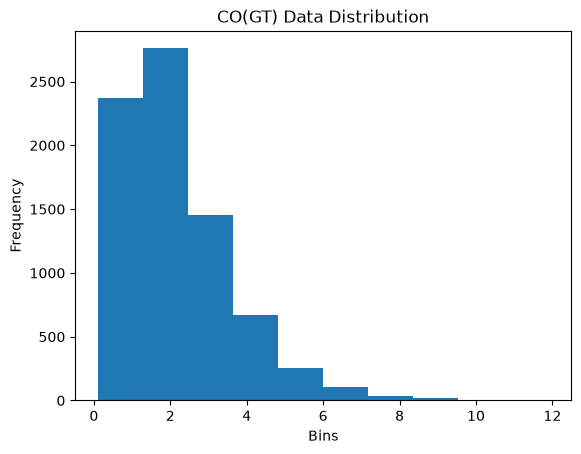

In [152]:
plt.hist(df['CO(GT)'], bins=10)
plt.title('CO(GT) Data Distribution')
plt.xlabel('Bins')
plt.ylabel('Frequency')
plt.show()

Do the same for NMHC(GT)! Try changing the bin size.

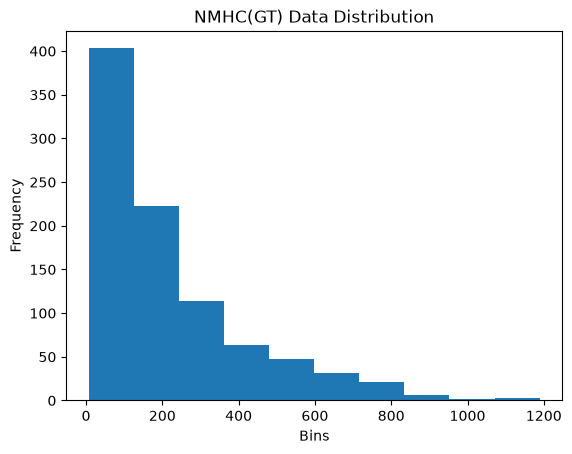

In [153]:
plt.hist(df['NMHC(GT)'], bins=10)
plt.title('NMHC(GT) Data Distribution')
plt.xlabel('Bins')
plt.ylabel('Frequency')
plt.show()

### Pair Plot

What we want to know is what is the best feature to predict temperature?

So, we need to plot each feature against temperature, or `df['T']`. But eyeballing 12 scatter plots can be misleading, especially when there are thousands of overlapping points. To make this rigorous, we'll also compute the **Pearson correlation coefficient** (`r`) between each feature and `T`. `r` ranges from -1 to 1: values near 0 mean little to no linear relationship, and values close to -1 or 1 mean a strong negative or positive linear relationship.

We'll sort the features by how strongly they correlate with temperature, and plot the strongest relationships first.

In [141]:
# Correlation of every feature with Temperature (T), sorted by strength (ignoring NaNs automatically)
correlations = df.drop(columns='T').corrwith(df['T']).sort_values(key=abs, ascending=False)

print(correlations)

AH               0.656397
RH              -0.578621
PT08.S4(NO2)     0.561270
NMHC(GT)         0.391587
NOx(GT)         -0.269683
PT08.S2(NMHC)    0.241373
C6H6(GT)         0.198956
NO2(GT)         -0.186533
PT08.S3(NOx)    -0.145112
PT08.S1(CO)      0.048627
PT08.S5(O3)     -0.027172
CO(GT)           0.022109
dtype: float64


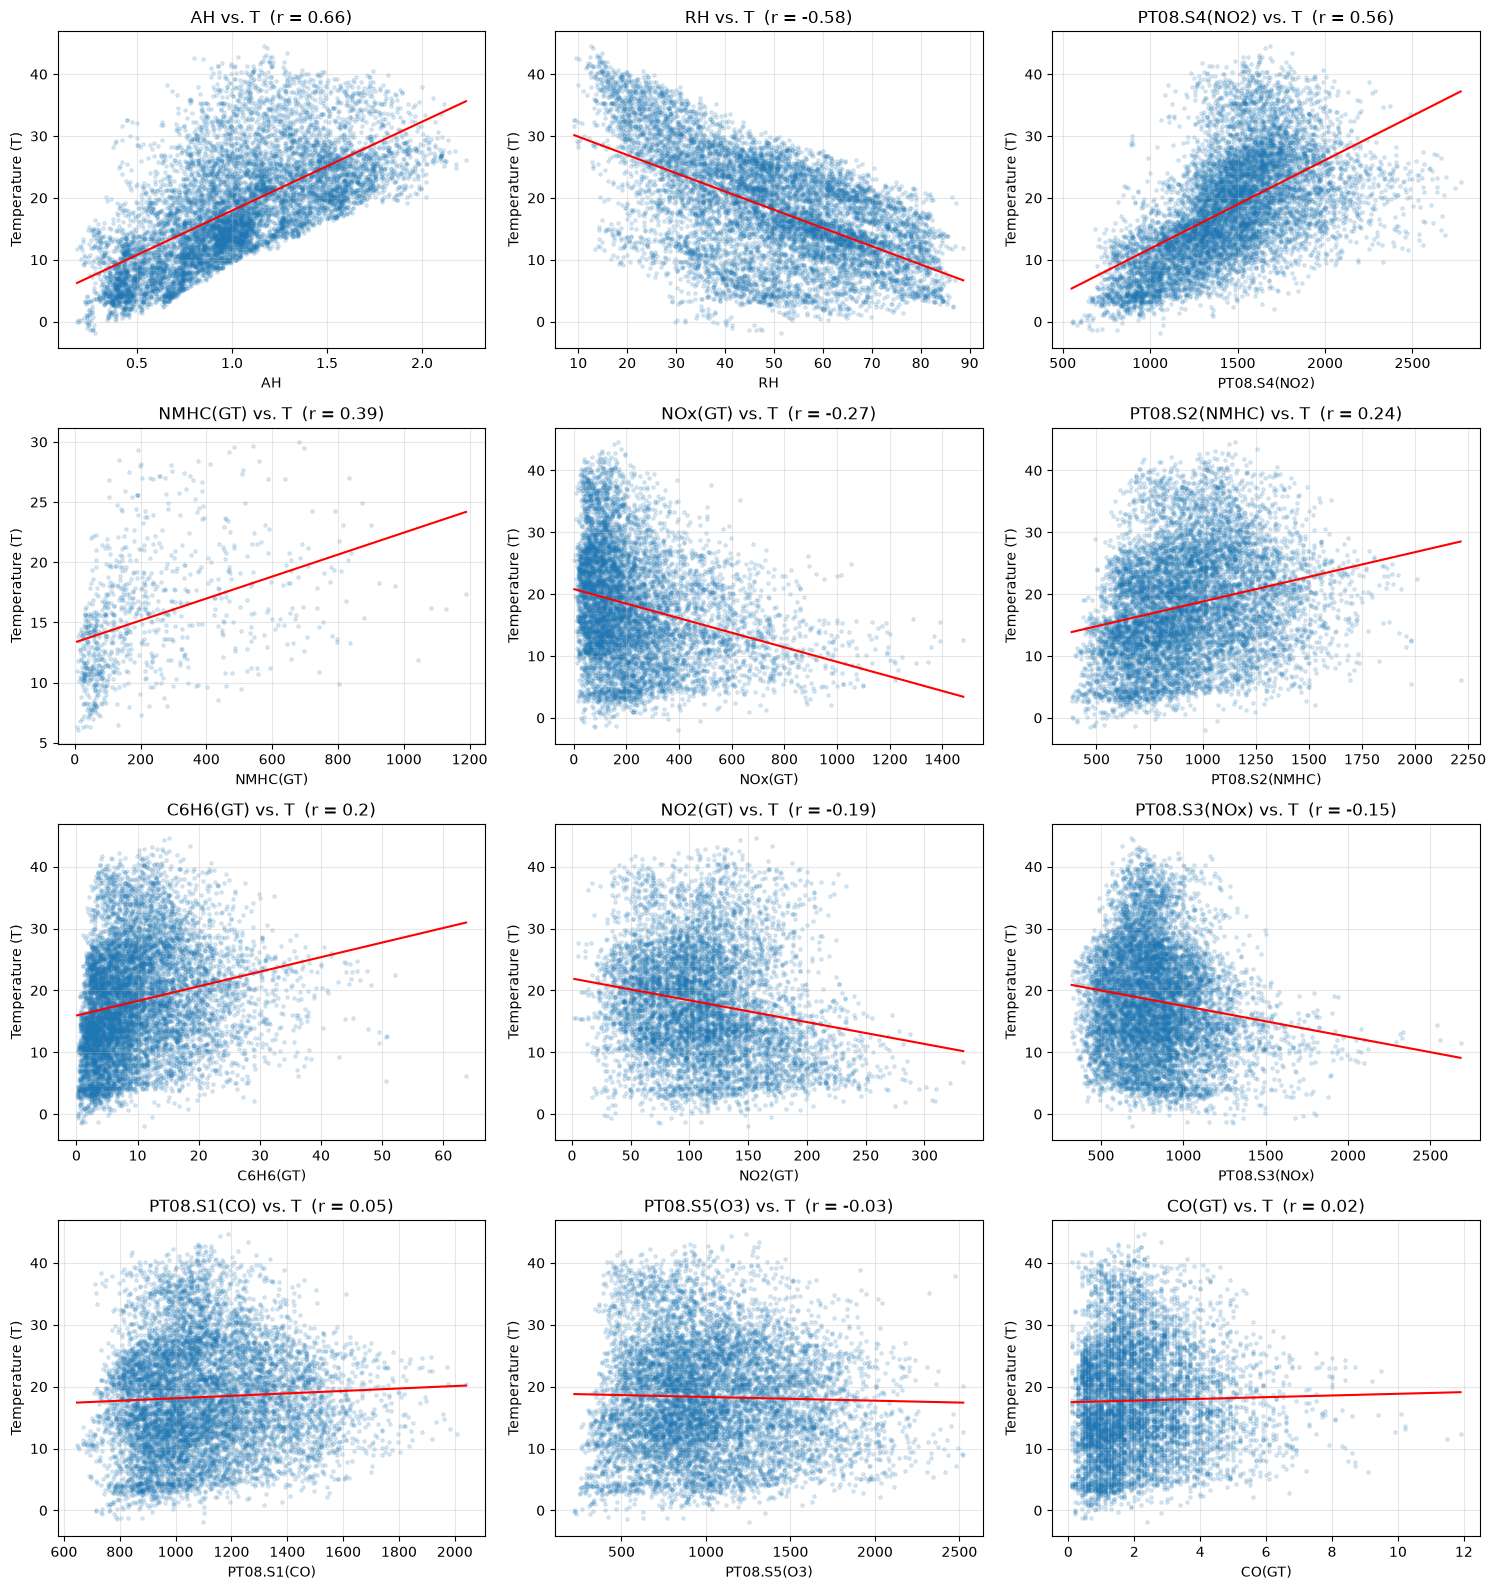

In [ ]:
# Plot features in order of correlation strength, strongest first
features_sorted = correlations.index

fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(15, 16)
)

for ax, feature in zip(axes.ravel(), features_sorted):
    r = correlations[feature]

    # Lower alpha and marker size since we have thousands of overlapping points
    ax.scatter(df[feature], df['T'], alpha=0.15, s=6)

    # Add a trend line so the relationship is visible through the noise
    valid = df[[feature, 'T']].dropna()
    coeffs = np.polyfit(valid[feature], valid['T'], 1)
    x_line = np.linspace(valid[feature].min(), valid[feature].max(), 100)
    ax.plot(x_line, np.polyval(coeffs, x_line), color='red', linewidth=1.5)

    ax.set_xlabel(feature)
    ax.set_ylabel('Temperature (T)')
    ax.set_title(f'{feature} vs. T  (r = {round(r, 2)})')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

**What do we see?** `AH` (absolute humidity) has the strongest relationship with temperature (r $\approx$ 0.66), followed by `RH` (relative humidity, r $\approx$ -0.58) and `PT08.S4(NO2)` (r $\approx$ 0.56). This matches physical intuition, humidity and temperature are closely linked. Meanwhile, `CO(GT)`, `PT08.S5(O3)`, and `PT08.S1(CO)` barely correlate with temperature at all (r close to 0), and their trend lines are nearly flat.

One caution: `NMHC(GT)` shows a moderate r ($\approx$ 0.39), but remember from earlier that about 90% of its values were missing. A correlation computed from the remaining 10% of the data is much less reliable, so we shouldn't put too much trust in that number.

Based on this, **`AH` looks like our best single feature for predicting temperature** so we'll use it in the next section!

# References

Vito, S. (2008). Air Quality [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C59K5F.